In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve
)

# Set plot style
sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


In [10]:
# Load CSV dataset
df = pd.read_csv('svm_dataset.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (100000, 21)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,target
0,7.998413,0.984739,0.290672,1.793611,3.141796,6.371760,-3.362452,4.337359,4.856219,-0.957387,...,0.992413,3.002265,0.056919,-12.866365,0.053413,1.608563,3.627025,-10.531833,-1.080657,1
1,3.039840,-2.464692,0.157561,1.364657,-1.022825,-2.891662,-1.622489,-0.549794,-0.713191,-4.975356,...,5.886447,-10.065036,-0.874080,-3.724132,-7.980677,-3.069656,-1.857197,12.090917,5.659710,1
2,7.220934,0.542537,0.341192,0.783758,-0.720299,1.660144,-0.493794,-2.349186,2.344194,-0.765457,...,2.615312,1.825366,1.627690,-1.576416,-6.707107,-1.946025,-3.383272,8.215807,-1.667561,1
3,6.340257,-0.376295,1.457872,-2.403226,-2.843702,-1.858997,2.372373,-5.137676,3.057494,-2.459847,...,-2.256398,6.199751,-0.197597,10.205720,6.037954,0.353179,1.803081,8.023637,2.484765,0
4,2.520337,-0.717631,-0.652892,-0.588046,-1.690060,0.373458,1.175797,-0.569676,1.200102,0.511649,...,0.215089,1.903141,-0.423151,1.379100,-0.987010,-3.346959,-0.872682,4.550860,0.103879,1


In [11]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 80000
Testing samples:  20000


In [12]:
# Define Numerical Pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3, random_state=42))
])

# Measure training time
start_time = time.time()
svm_pipeline.fit(X_train, y_train)
training_time = time.time() - start_time

print(f'Numerical Pipeline successfully trained in {training_time:.4f} seconds.')

Numerical Pipeline successfully trained in 0.5257 seconds.


In [13]:
y_pred = svm_pipeline.predict(X_test)
decision_scores = svm_pipeline.decision_function(X_test)

print(f'Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Overall Accuracy: 80.07%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      9995
           1       0.79      0.81      0.80     10005

    accuracy                           0.80     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.80      0.80      0.80     20000



C:\Users\Acer\AppData\Local\Temp\ipykernel_3128\1689064860.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients[sorted_idx[:10]], y=feature_names[sorted_idx[:10]], palette='vlag', ax=axes[1, 1])


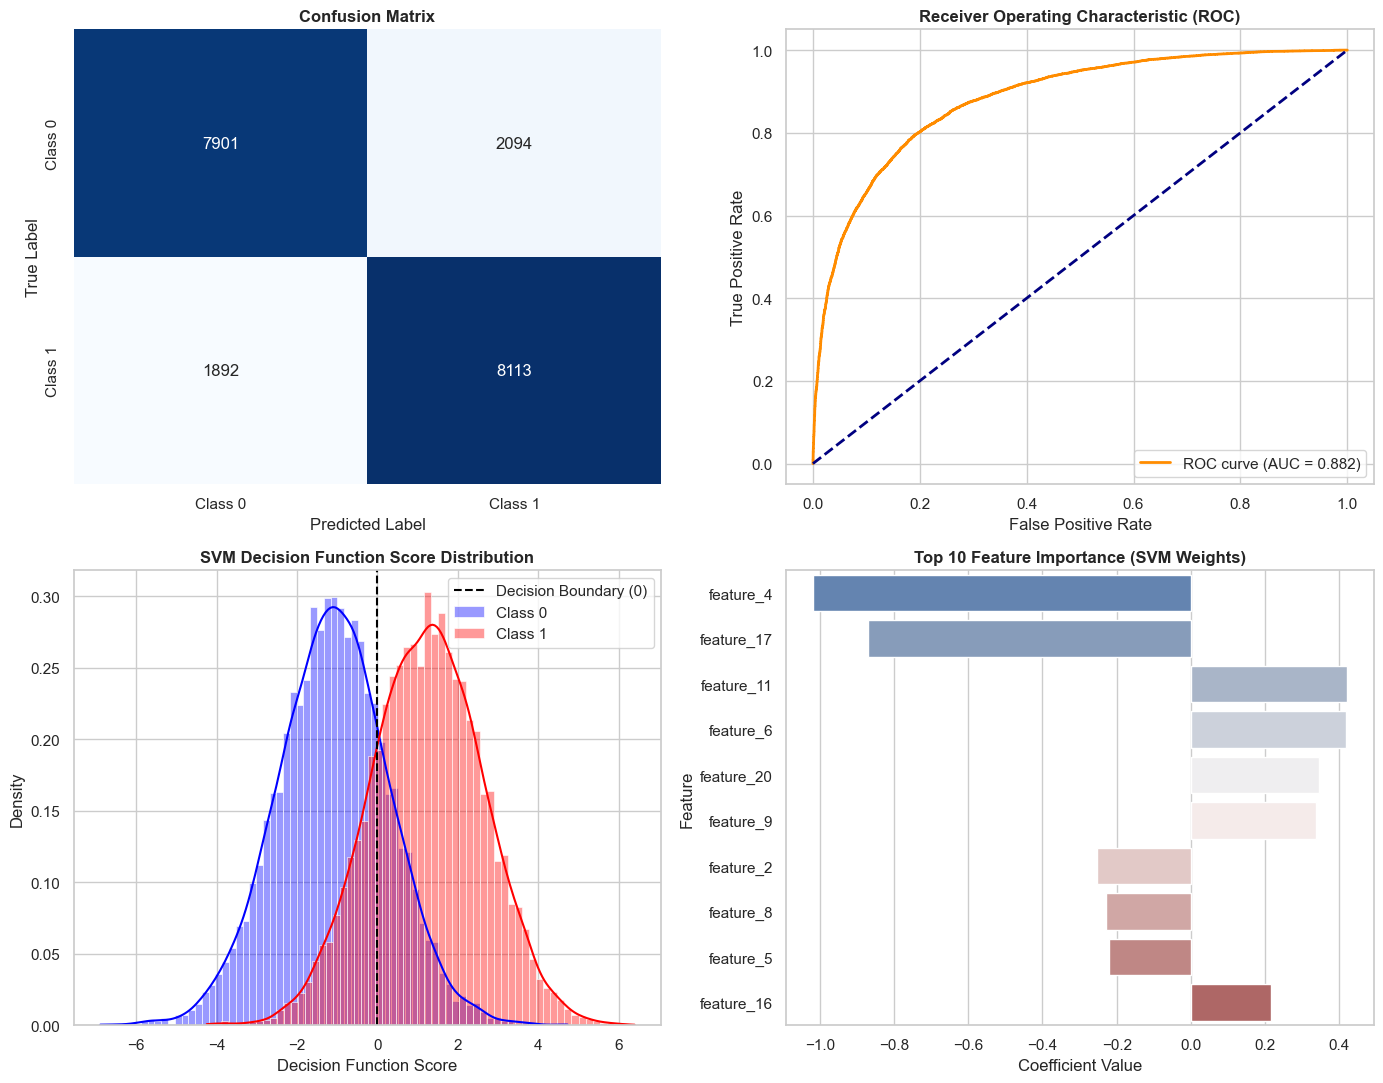

In [14]:
# Create figure layout
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xticklabels(['Class 0', 'Class 1'])
axes[0, 0].set_yticklabels(['Class 0', 'Class 1'])

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')

# 3. Decision Score Distribution
sns.histplot(decision_scores[y_test == 0], color='blue', label='Class 0', kde=True, ax=axes[1, 0], stat='density', alpha=0.4)
sns.histplot(decision_scores[y_test == 1], color='red', label='Class 1', kde=True, ax=axes[1, 0], stat='density', alpha=0.4)
axes[1, 0].axvline(0, color='black', linestyle='--', label='Decision Boundary (0)')
axes[1, 0].set_title('SVM Decision Function Score Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Decision Function Score')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# 4. Feature Weights (Top Coefficients)
coefficients = svm_pipeline.named_steps['svm'].coef_[0]
feature_names = X.columns
sorted_idx = np.argsort(np.abs(coefficients))[::-1]

sns.barplot(x=coefficients[sorted_idx[:10]], y=feature_names[sorted_idx[:10]], palette='vlag', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Feature Importance (SVM Weights)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Coefficient Value')
axes[1, 1].set_ylabel('Feature')

plt.tight_layout()
plt.show()